## Task 20

20a) + 20b)

In [31]:
import numpy as np
from scipy.sparse import diags, kron, eye, csr_matrix, csr_array
from scipy.sparse.linalg import expm
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [32]:
def init_state(N, m):
    """Initialize the ground state of the system."""
    state = np.zeros(N+1, dtype=complex)
    x = int(N/2 + m)
    state[x] = 1.0
    return state

def J_minus(N):
    """J- operator as a sparse matrix."""
    dim = N + 1
    m_vals = np.linspace(-N/2 + 1, N/2, N)
    data = np.sqrt((N/2 + m_vals) * (N/2 - m_vals + 1))
    return diags(data, offsets=1, shape=(dim, dim), format='csr')

def J_plus(N):
    """J+ operator as a sparse matrix."""
    dim = N + 1
    m_vals = np.linspace(-N/2, N/2-1, N)
    data = np.sqrt((N/2 - m_vals) * (N/2 + m_vals + 1))
    return diags(data, offsets=-1, shape=(dim, dim), format='csr')

def J_Z(N):
    """Jz operator as a sparse matrix."""
    m_vals = np.linspace(-N/2, N/2, N+1)
    return diags(m_vals, offsets=0, shape=(N+1, N+1), format='csr')

def rho_vector_state(state):
    """Convert density matrix to vector state."""
    return np.kron(state, state.conj()).flatten()
    
def construct_superoperator(N, Omega, gamma):
    """Construct sparse superoperator for Lindblad dynamics."""
    dim = N + 1
    Jp = J_plus(N)
    Jm = J_minus(N)
    Jx = (Jp + Jm) / 2.0
    I = eye(dim, format='csr')
    
    A = kron(Jx, I, format='csr')
    B = kron(I, Jx.T, format='csr')
    H_term = -1j * Omega * N * (A - B)
    
    L1 = 2 * kron(Jm, Jp.T, format='csr')
    L2 = kron(Jp @ Jm, I, format='csr')
    L3 = kron(I, (Jp @ Jm).T, format='csr')
    dissipator = gamma/2 * (L1 - L2 - L3)
    
    return H_term + dissipator

All states are valid.


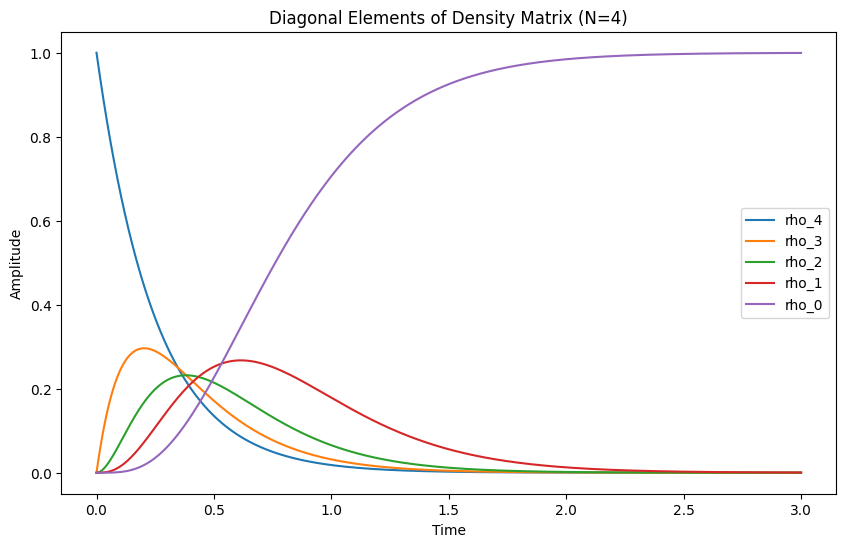

In [33]:

N = 4
Gamma = 1.0
Omega = 0.0
dim = N + 1

L = construct_superoperator(N, Omega, Gamma)

t_span = (0, 3)
t_eval = np.linspace(t_span[0], t_span[1], 1000)
rho0 = rho_vector_state(init_state(N, 2))

sol = solve_ivp(lambda t, y: L @ y, t_span, rho0, t_eval=t_eval, method='BDF')
rho_t = sol.y.real

diag_indices = [i*(dim+1) for i in range(dim)]

valid_state = True
for i in range(len(t_eval)):
    diag_sum = rho_t[diag_indices, i].sum()
    if not np.isclose(diag_sum, 1.0, atol=1e-5):
        valid_state = False
        break

print("All states are valid." if valid_state else "Invalid states detected.")

plt.figure(figsize=(10, 6))
plt.plot(t_eval, rho_t[24], label="rho_4")
plt.plot(t_eval, rho_t[18], label='rho_3')
plt.plot(t_eval, rho_t[12], label='rho_2')
plt.plot(t_eval, rho_t[6], label='rho_1')
plt.plot(t_eval, rho_t[0], label='rho_0')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Diagonal Elements of Density Matrix (N=4)')
plt.show()


Normalized population inversion:

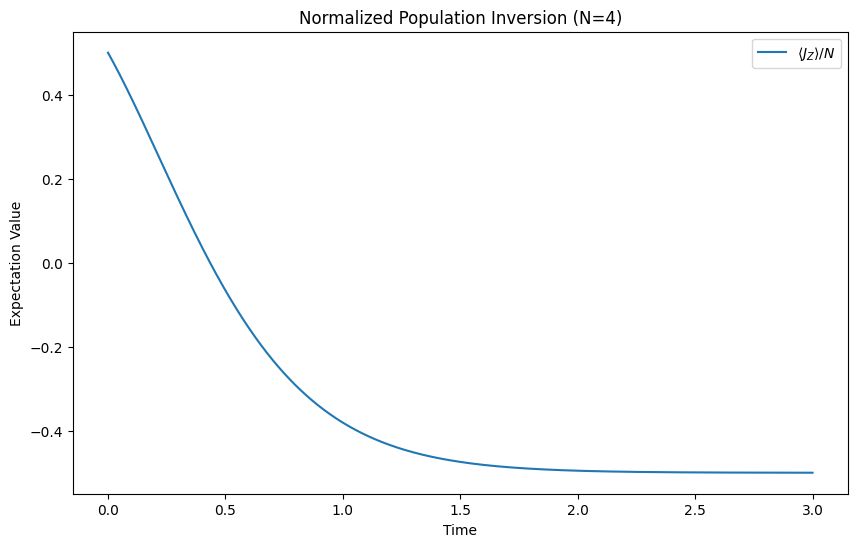

In [34]:
jz = J_Z(N).diagonal()
y_vals = np.zeros(len(t_eval))
for i in range(len(t_eval)):

    diag_rho = rho_t[[idx for idx in diag_indices], i]
    y_vals[i] = np.dot(diag_rho, jz) / N

plt.figure(figsize=(10, 6))
plt.plot(t_eval, y_vals, label=r'$\langle J_Z \rangle / N$')
plt.title("Normalized Population Inversion (N=4)")
plt.xlabel('Time')
plt.ylabel('Expectation Value')
plt.legend()
plt.show()

Emitted photon current:

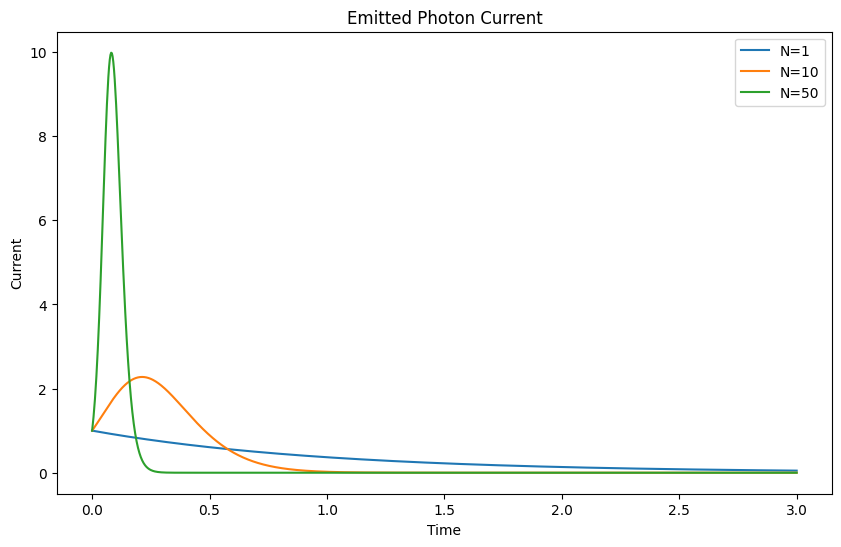

In [35]:
N_vector = [1, 10, 50]
Gamma = 1.0
Omega = 0.0
t_span = (0, 3)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

currents = []

for N in N_vector:
    dim = N + 1
    
    L = construct_superoperator(N, Omega, Gamma)
    JpJm = (J_plus(N) @ J_minus(N)).diagonal()  
    
    rho0 = rho_vector_state(init_state(N, N/2))
    
    sol = solve_ivp(lambda t, y: L @ y, t_span, rho0, t_eval=t_eval, method='BDF')
    rho_t = sol.y.real
    
    diag_indices = [i*(dim+1) for i in range(dim)]
    current = np.zeros(len(t_eval))
    
    for i in range(len(t_eval)):
        diag_rho = rho_t[[idx for idx in diag_indices], i]
        current[i] = np.dot(diag_rho, JpJm) / N  
    
    currents.append(current)

plt.figure(figsize=(10, 6))
for i, N in enumerate(N_vector):
    plt.plot(t_eval, currents[i], label=f'N={N}')

plt.title("Emitted Photon Current")
plt.xlabel('Time')
plt.ylabel('Current')
plt.legend()
plt.show()


For N = 1 we can see the usual exponetial we are used to. We can see the emission becoming burst like for increasing N. So more atoms in a cavity emit in a burst, and very much not independant of each other!

Part 20c)

In [36]:
Omega_vals = np.linspace(0, 1, 9)
Gamma = 1.0  
t_span_new = (0, 10)
t_eval_new = np.linspace(*t_span_new, 1000)

In [37]:
# We have computational issues so I precompute parts of L to save some kronecker products

def precompute_operators(N, Gamma):
    dim = N + 1
    Jp = J_plus(N)
    Jm = J_minus(N)
    Jx = (Jp + Jm) / 2.0
    I = eye(dim, format='csr')
    
    A = kron(Jx, I, format='csr')
    B = kron(I, Jx.T, format='csr')
    L0_ham = -1j * N * (A - B)

    L1 = 2 * kron(Jm, Jp.T, format='csr')
    L2 = kron(Jp @ Jm, I, format='csr')
    L3 = kron(I, (Jp @ Jm).T, format='csr')
    L_diss = Gamma/2 * (L1 - L2 - L3)
    
    return L0_ham, L_diss

def J_Z_plot(N, Gamma, rtol=1e-4, atol=1e-7):
    dim = N + 1
    L0_ham, L_diss = precompute_operators(N, Gamma)
  
    diag_indices = np.arange(0, dim**2, dim+1)
    jz_vals = J_Z(N).diagonal()
    rho0 = rho_vector_state(init_state(N, N/2))
    
    for omega in Omega_vals:

        L = omega * L0_ham + L_diss
        
        sol = solve_ivp(
            fun=lambda t, y: L @ y,
            t_span=t_span_new,
            y0=rho0,
            t_eval=t_eval_new,
            method='BDF',
            rtol=rtol,
            atol=atol
        )
        
        # Vectorized expectation value calculation
        diag_rho = sol.y[diag_indices].real
        y_vals = jz_vals @ diag_rho / N 
        
        plt.plot(t_eval_new, y_vals, label=f'Ω={omega:.2f}')
        print("step", omega*8)
        
    plt.title(f"⟨Ĵ_z⟩/N vs Time (N={N})")
    plt.xlabel('Time')
    plt.ylabel(r'$\langle \hat{J}_z \rangle / N$')
    plt.legend()


def J_Y_plot(N):
    dim = N + 1
    J_y = 1j * (J_minus(N) - J_plus(N)) / (2*N)
    I_sparse = eye(dim, format='csr')
    
    M = kron(I_sparse, J_y.T, format='csr') 
   
    diag_indices = np.arange(0, (dim)**2, dim + 1)
    I_vec = np.zeros((dim)**2)
    I_vec[diag_indices] = 1.0
    rho0 = rho_vector_state(init_state(N, N/2))

    L0_ham, L_diss = precompute_operators(N, Gamma)

    for omega in Omega_vals:
        L = omega * L0_ham + L_diss
    
        sol = solve_ivp(lambda t, y: L @ y, t_span_new, rho0, 
                        t_eval=t_eval_new, method='BDF')
        rho_t = sol.y 
        
        y_vals = np.zeros(len(t_eval_new))
        for i in range(len(t_eval_new)):
            M_rho = M @ rho_t[:, i]
            val = np.vdot(I_vec, M_rho)
            y_vals[i] = val  
        plt.plot(t_eval_new, y_vals, label=f'Omega={omega:.2f}')
        print("step", omega*8)
    
    plt.title(f"Expectation Value of J_Y for Varying Omega (N={N})")
    plt.xlabel('Time')
    plt.ylabel(r'$\langle \hat{J}_z \rangle / N$')
    plt.legend()



step 0.0
step 1.0
step 2.0
step 3.0
step 4.0
step 5.0
step 6.0
step 7.0
step 8.0


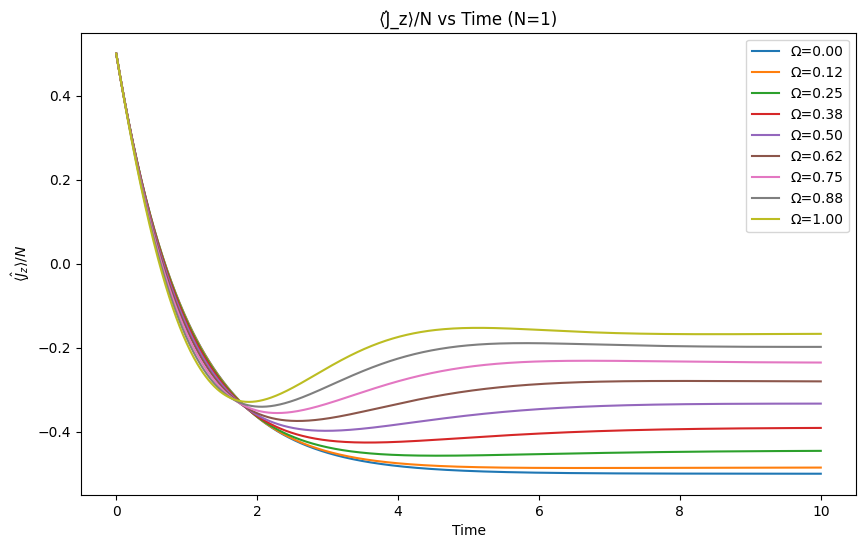

In [38]:
plt.figure(figsize=(10, 6))
J_Z_plot(1, Gamma, rtol=1e-3, atol=1e-5)
plt.show()

step 0.0
step 1.0
step 2.0
step 3.0
step 4.0
step 5.0
step 6.0
step 7.0
step 8.0


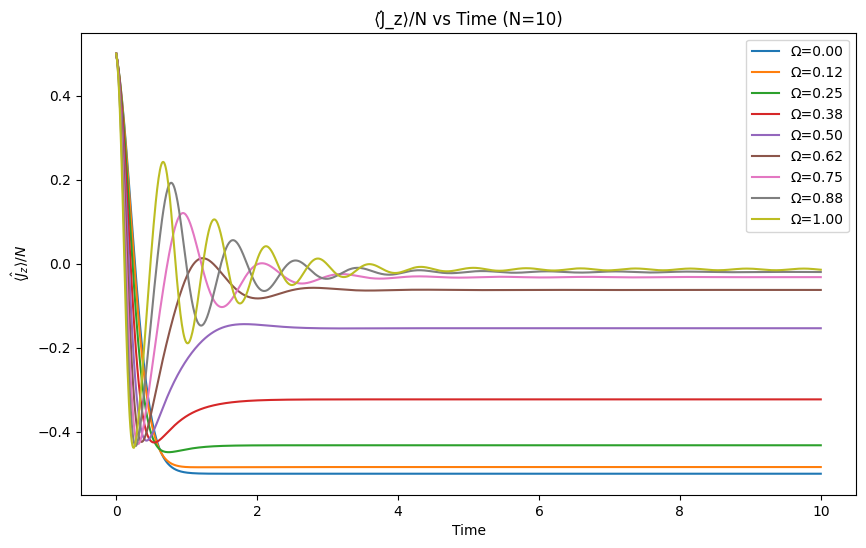

In [39]:
plt.figure(figsize=(10, 6))
J_Z_plot(10, Gamma, rtol=1e-3, atol=1e-5)
plt.show()

step 0.0
step 1.0
step 2.0
step 3.0
step 4.0
step 5.0
step 6.0
step 7.0
step 8.0


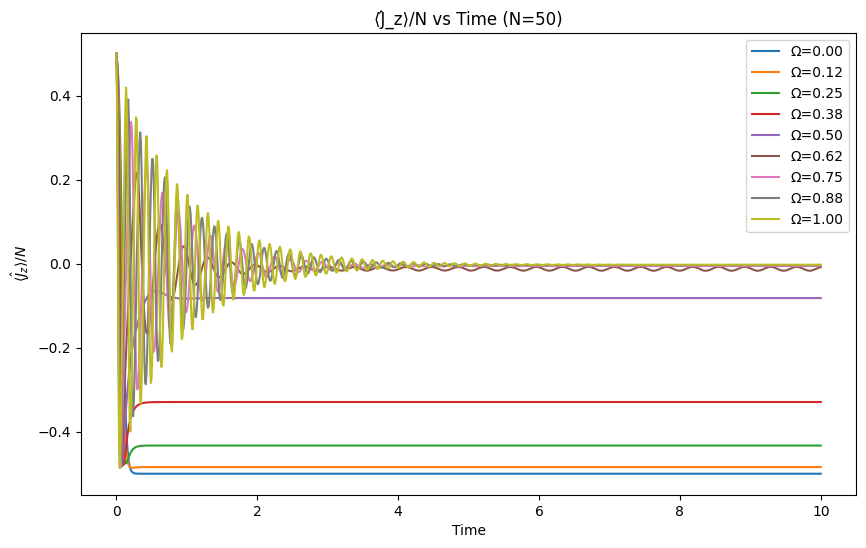

In [40]:
plt.figure(figsize=(10, 6))
J_Z_plot(50, Gamma, rtol=1e-3, atol=1e-5)
plt.show()

We can observe a transition from the steady state of J_z from the miminum to zero for $\omega$ larger than 0.5

C:\Users\tilln\AppData\Local\Temp\ipykernel_13108\239381060.py:81: ComplexWarning: Casting complex values to real discards the imaginary part
  y_vals[i] = val


step 0.0
step 1.0
step 2.0
step 3.0
step 4.0
step 5.0
step 6.0
step 7.0
step 8.0


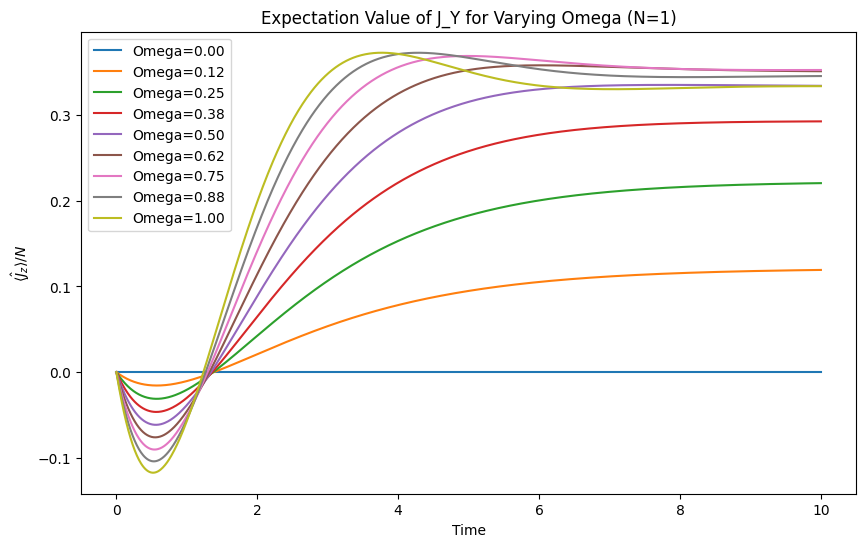

In [41]:
plt.figure(figsize=(10, 6))
J_Y_plot(1)
plt.show()

C:\Users\tilln\AppData\Local\Temp\ipykernel_13108\239381060.py:81: ComplexWarning: Casting complex values to real discards the imaginary part
  y_vals[i] = val


step 0.0
step 1.0
step 2.0
step 3.0
step 4.0
step 5.0
step 6.0
step 7.0
step 8.0


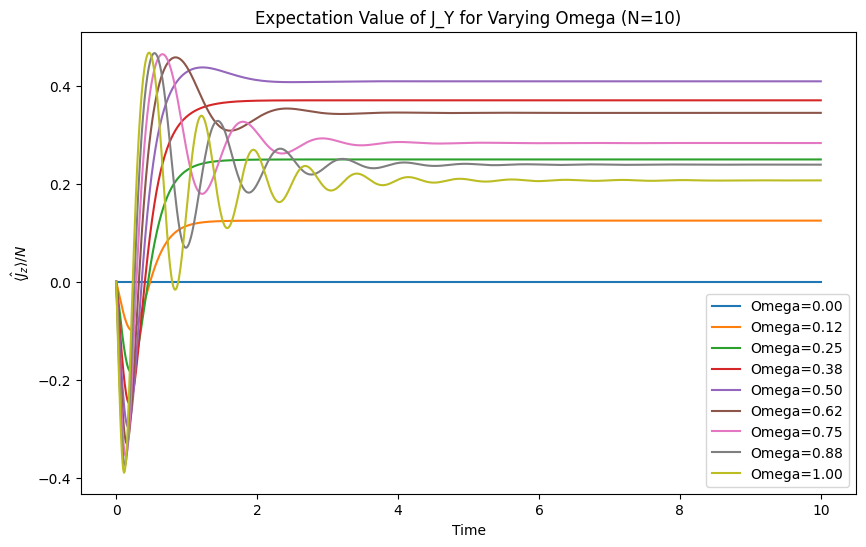

In [42]:
plt.figure(figsize=(10, 6))
J_Y_plot(10)
plt.show()

C:\Users\tilln\AppData\Local\Temp\ipykernel_13108\239381060.py:81: ComplexWarning: Casting complex values to real discards the imaginary part
  y_vals[i] = val


step 0.0
step 1.0
step 2.0
step 3.0
step 4.0
step 5.0
step 6.0
step 7.0
step 8.0


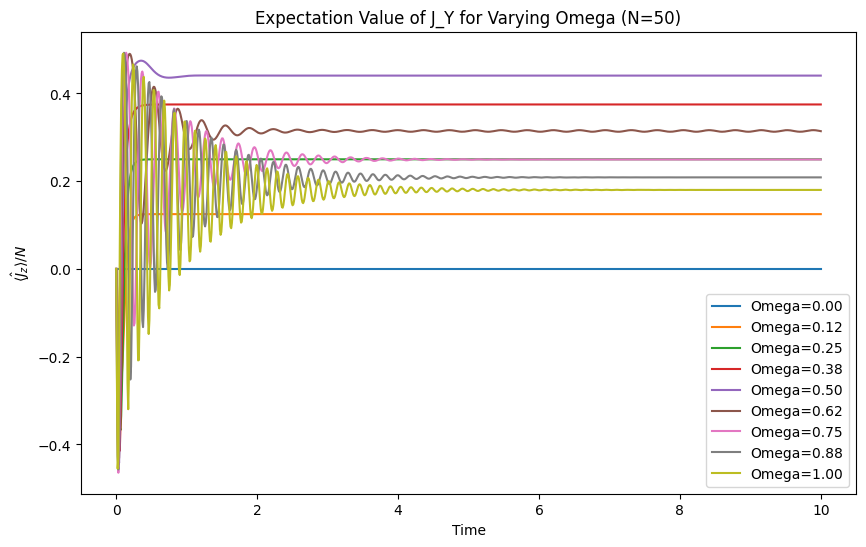

In [43]:
plt.figure(figsize=(10, 6))
J_Y_plot(50)
plt.show()

We can observe the maximum of the steady state amplitude of J_y being reached for $\omega$ = 0.5

Numpy based approach: (inefficient first attempt)

All states are valid with trace equal to 1 for all time steps.


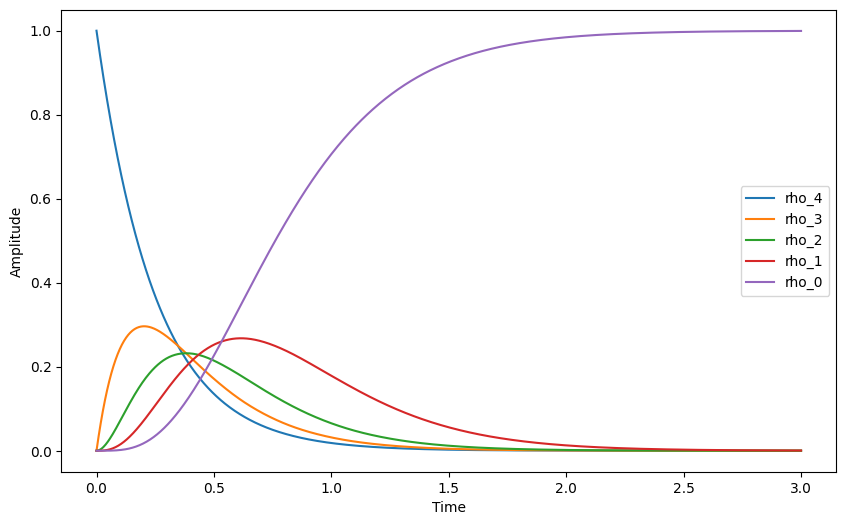

In [44]:
def init_state(N, m):
    """Initialize the ground state of the system."""
    state = np.zeros((N+1, 1), dtype=complex) 
    x = int(N/2 + m)
    state[x] = 1.0
    return state  

N = 4
Gamma = 1.0
Omega = 0

def J_minus(N):

    def factorfunc_minus(m):
        return np.sqrt((N/2 + m)*(N/2 -m+1))

    vec = factorfunc_minus(np.linspace(-N/2 +1, N/2, N))
    
    A = np.diag(vec, +1)

    return A

def J_plus(N):

    def factorfunc_plus(m):
        return np.sqrt((N/2 - m)*(N/2 +m+1))

    vec = factorfunc_plus(np.linspace(-N/2, N/2-1, N))
    
    A = np.diag(vec, -1)

    return A
    

def rho_vector_state(state):
    """Convert the density matrix to a vector state."""
    return np.kron(state, state.conjugate()).flatten()


def rhodot(t, rho, N, Omega, gamma):
    dim = N + 1
    J_X = (J_plus(N) + J_minus(N)) / 2
    evolved = -1j*Omega*N*(np.kron(J_X, np.identity(dim)) @ rho - np.kron(np.identity(dim), J_X.T) @ rho)
    evolved += gamma/2 *((2 * np.kron(J_minus(N), J_plus(N).T)) @ rho - np.kron(J_plus(N) @ J_minus(N), np.identity(dim)) @ rho - np.kron(np.identity(dim), (J_plus(N) @ J_minus(N)).T) @ rho) 

    return evolved

t_span = np.linspace(0, 3, 1000)
sol = solve_ivp(rhodot,(t_span[0],t_span[-1]),rho_vector_state(init_state(4,2)).flatten(),t_eval=t_span, args=[N,Omega,Gamma])
rho_t = sol.y.real


dim = N + 1
valid_state = True

for i in range(len(t_span)):
    rho_matrix = rho_t[:, i].reshape((dim, dim))
    trace = np.trace(rho_matrix)
    if not np.isclose(trace, 1):
        valid_state = False
    break

if valid_state:
    print("All states are valid with trace equal to 1 for all time steps.")
else:
    print("Some states are invalid with trace not equal to 1.")


plt.figure(figsize=(10, 6))
plt.plot(t_span, rho_t[24], label="rho_4")
plt.plot(t_span, rho_t[18], label='rho_3')
plt.plot(t_span, rho_t[12], label='rho_2')
plt.plot(t_span, rho_t[6], label='rho_1')
plt.plot(t_span, rho_t[0], label='rho_0')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()